In [103]:
import pandas as pd
import os
import kagglehub
from dotenv import load_dotenv
import numpy as np

In [104]:
#Load .env file for Kaggle Credentials 
load_dotenv()
username = os.getenv("KAGGLE_USERNAME")
key = os.getenv("KAGGLE_KEY")

os.environ["KAGGLE_USERNAME"] = username
os.environ["KAGGLE_KEY"] = key

In [105]:
#Locate path to the Kaggle dataset
path = kagglehub.dataset_download(
    "aiaiaidavid/the-big-dataset-of-ultra-marathon-running"
)

In [ ]:
df = pd.read_csv(f"{path}/TWO_CENTURIES_OF_UM_RACES.csv", encoding="latin1")
df = df.drop(columns=["Event dates", "Athlete club", "Event number of finishers", "Athlete average speed"])

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 1 — PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

# a. Extract recent year data as the timining is more accurate
df = df[df['Year of event'] >= 2000] 

# b. Filter for athletes that have a longer career
threshold_of_races = 15
valid_athletes = df['Athlete ID'].value_counts()
valid_athletes = valid_athletes[valid_athletes > threshold_of_races].index
experienced_df = df[df['Athlete ID'].isin(valid_athletes)]
print(f"Number of experienced athletes: {experienced_df['Athlete ID'].nunique()}")

# c. Extract races of length 56km
df_56km = experienced_df[experienced_df['Event distance/length'] == '56km'].copy()
print(f"Number 56km race entries: {len(df_56km)}")

Number of experienced athletes: 81603
Number 56km race entries: 84119


In [ ]:
df_56km["distance_km"] = df_56km["Event distance/length"].str.extract(r"(\d+\.?\d*)").astype(float)

time_parts = df_56km["Athlete performance"].str.replace(" h", "").str.split(":", expand=True)

df_56km["hours"] = (
    time_parts[0].astype(float) +
    time_parts[1].astype(float) / 60 +
    time_parts[2].astype(float) / 3600
)


df_56km["calculated_speed"] = df_56km["distance_km"] / df_56km["hours"]

df_56km["finish_time_mins"] = df_56km["hours"] * 60

df_56km["calculated_speed"].head()

55099    11.752361
55100    11.721612
55101    11.035691
55102    10.987574
55103     9.766022
Name: calculated_speed, dtype: float64

In [ ]:
threshold = df_56km["calculated_speed"].quantile(0.90)

df_top10 = df_56km[df_56km["calculated_speed"] >= threshold].copy()

df_top10["finish_time_mins"] = df_top10["hours"] * 60

print(f"Top 10% Entries: {len(df_top10)}\n")
print(df_top10["calculated_speed"].describe())

Top 10% Entries: 8413

count    8413.000000
mean       13.436887
std         1.207065
min        12.046609
25%        12.482972
50%        13.088359
75%        14.120614
max        18.096948
Name: calculated_speed, dtype: float64


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
# a. Athlete Age
df_top10["athlete_age"] = df_top10["Year of event"] - df_top10["Athlete year of birth"]

# b. Age squared - captures non-linear age effect (performance peaks then declines)
df_top10["athlete_age_squared"] = df_top10["athlete_age"] ** 2

# c. Gender - binary encode
df_top10["gender_male"] = (df_top10["Athlete gender"] == "M").astype(int)

# e. Age from peak (marathon peak age ~28-32, using 30 as midpoint)
df_top10["age_from_peak"] = abs(df_top10["athlete_age"] - 30)

# f. Experience - log transform to diminish returns of extra races
# log(1 + x) ensures athletes with 0 previous races don't cause log(0)
df_top10["race_count"] = df_top10.groupby("Athlete ID")["Athlete ID"].transform("count")
df_top10["experience_log"] = np.log1p(df_top10["race_count"])

# g. Age x Gender interaction
df_top10["age_gender"] = df_top10["athlete_age"] * df_top10["gender_male"]

# h. Age x log(experience) interaction
df_top10["age_x_experience"] = df_top10["athlete_age"] * df_top10["experience_log"]

In [ ]:
#Features derived from athlete's career

# a. average performance of field for races during the training data
df_top10["event_mean_trend"] = (
    df_top10[df_top10["Year of event"] < 2015]
    .groupby(["Event name"])["finish_time_mins"]
    .mean()
)

# b. Cross-race improvement trend of athlete
df_top10 = df_top10.sort_values(["Athlete ID", "Year of event", "Event name"])

df_top10["improvement_trend"] = (
    df_top10.groupby("Athlete ID")["finish_time_mins"]
    .transform(lambda x: x.shift(1) - x.shift(2))
)

# c. Cross-race consistency
df_top10["performance_std"] = (
    df_top10.groupby("Athlete ID")["finish_time_mins"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).std())
)

In [ ]:
features = [
    "athlete_age",
    "athlete_age_squared",
    "gender_male",
    "age_from_peak",
    "experience_log",
    "age_gender",
    "age_x_experience",
    "event_mean_trend",
    "improvement_trend",
    "performance_std"
]

target = "finish_time_mins"

# 1. Correlation with TARGET
target_corr = df_top10[features + ["finish_time_mins"]].corr()["finish_time_mins"].sort_values()
print(target_corr)

print("-------------------------------------------------------------")

# 2. Feature-to-feature correlation — multicollinearity check  
feature_corr = df_top10[features].corr()
print(feature_corr)

experience_log         -0.373891
age_x_experience       -0.189174
performance_std        -0.081097
gender_male            -0.080054
improvement_trend       0.059276
age_gender              0.086816
athlete_age             0.243342
athlete_age_squared     0.243637
age_from_peak           0.245498
performance_vs_field    0.990721
finish_time_mins        1.000000
Name: finish_time_mins, dtype: float64
-------------------------------------------------------------
                      athlete_age  athlete_age_squared  gender_male  \
athlete_age              1.000000             0.992260     0.011856   
athlete_age_squared      0.992260             1.000000     0.015161   
gender_male              0.011856             0.015161     1.000000   
age_from_peak            0.957063             0.973297     0.016320   
experience_log           0.046800             0.049127     0.063712   
age_gender               0.622638             0.621298     0.778439   
age_x_experience         0.511009      

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

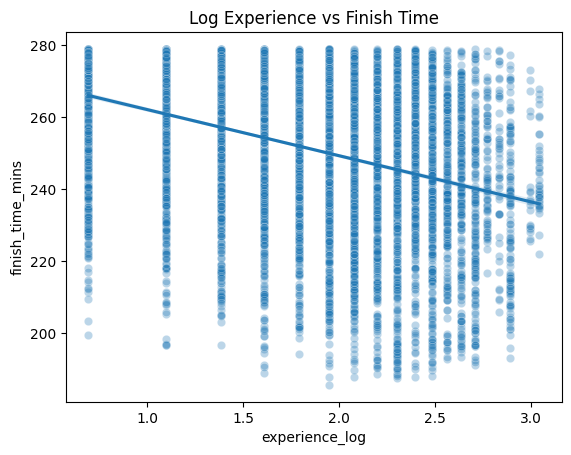

In [ ]:
plt.figure()
sns.scatterplot(x="experience_log", y="finish_time_mins", data=df_top10, alpha=0.3)
sns.regplot(x="experience_log", y="finish_time_mins", data=df_top10, scatter=False)
plt.title("Log Experience vs Finish Time")
plt.show()

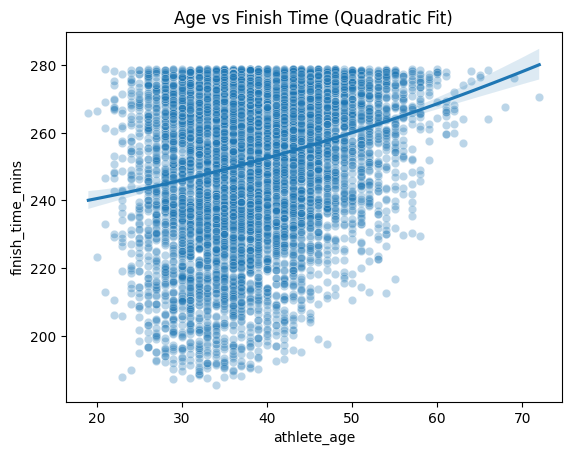

In [ ]:
plt.figure()
sns.scatterplot(x="athlete_age", y="finish_time_mins", data=df_top10, alpha=0.3)
sns.regplot(x="athlete_age", y="finish_time_mins", data=df_top10, scatter=False, order=2)
plt.title("Age vs Finish Time (Quadratic Fit)")
plt.show()

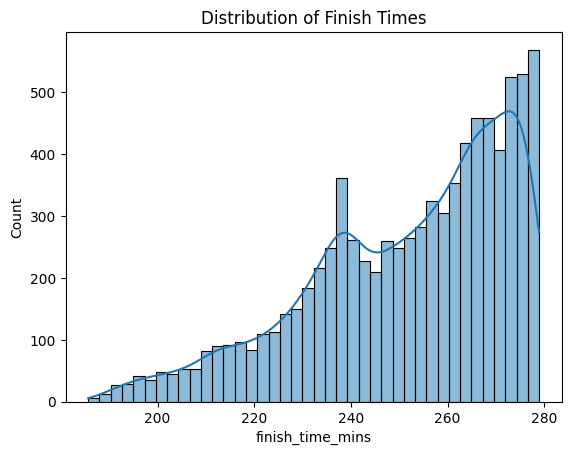

In [ ]:
plt.figure()
sns.histplot(df_top10["finish_time_mins"], bins=40, kde=True)
plt.title("Distribution of Finish Times")
plt.show()

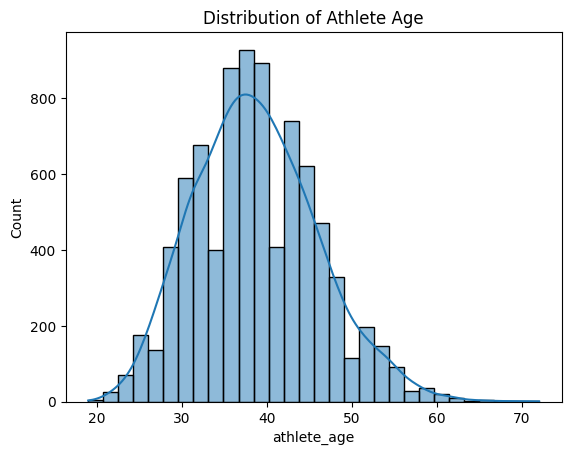

In [ ]:
plt.figure()
sns.histplot(df_top10["athlete_age"], bins=30, kde=True)
plt.title("Distribution of Athlete Age")
plt.show()

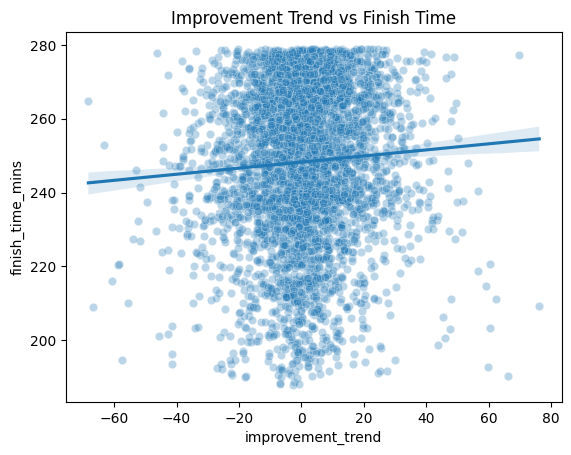

In [ ]:
plt.figure()
sns.scatterplot(x="improvement_trend", y="finish_time_mins", data=df_top10, alpha=0.3)
sns.regplot(x="improvement_trend", y="finish_time_mins", data=df_top10, scatter=False)
plt.title("Improvement Trend vs Finish Time")
plt.show()

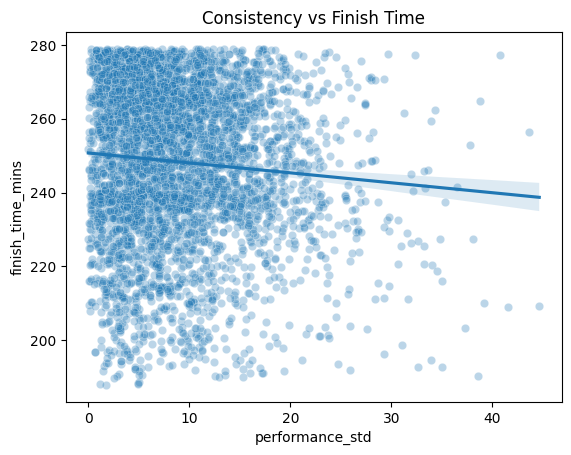

In [ ]:
plt.figure()
sns.scatterplot(x="performance_std", y="finish_time_mins", data=df_top10, alpha=0.3)
sns.regplot(x="performance_std", y="finish_time_mins", data=df_top10, scatter=False)
plt.title("Consistency vs Finish Time")
plt.show()

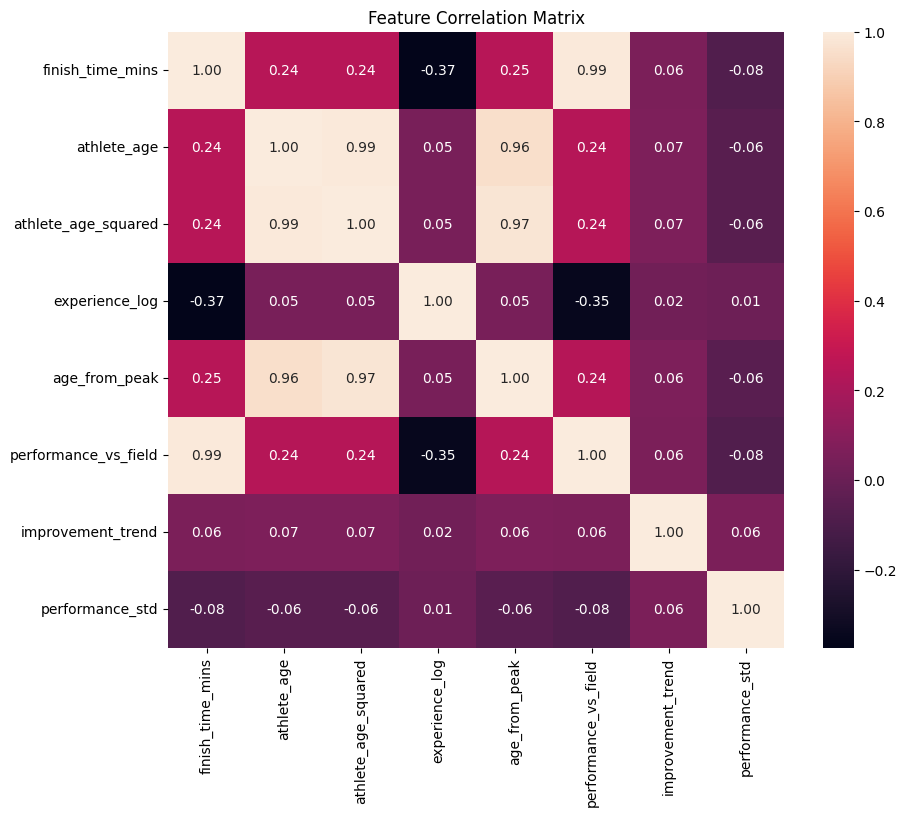

In [ ]:
plt.figure(figsize=(10, 8))
corr = df_top10[[
    "finish_time_mins",
    "athlete_age",
    "athlete_age_squared",
    "experience_log",
    "age_from_peak",
    "event_mean_trend",
    "improvement_trend",
    "performance_std"
]].corr()

sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3 — MODELING
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor 

In [ ]:
model_df = df_top10[features + [target, "Year of event"]].dropna()

In [ ]:
#TIME BASED MODEL SPLIT
train_df = model_df[model_df["Year of event"] <= 2015]
val_df   = model_df[(model_df["Year of event"] >= 2016) & (model_df["Year of event"] <= 2017)]
test_df  = model_df[model_df["Year of event"] >= 2018]

X_train, y_train = train_df[features], train_df[target]
X_val,   y_val   = val_df[features],   val_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 3412 | Val: 486 | Test: 435


In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform
X_val_s   = scaler.transform(X_val)         # transform only
X_test_s  = scaler.transform(X_test)        # transform only

In [ ]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"  MAE:  {mae:.2f} mins")
    print(f"  RMSE: {rmse:.2f} mins")
    print(f"  R²:   {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1 — LINEAR REGRESSION (Ridge for stability)
# ══════════════════════════════════════════════════════════════════════════════
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)

# Tune alpha on validation set
best_alpha, best_val_mae = 1.0, float("inf")
for alpha in [0.01, 0.1, 1, 10, 100]:
    m = Ridge(alpha=alpha).fit(X_train_s, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val_s))
    if mae < best_val_mae:
        best_val_mae, best_alpha = mae, alpha

ridge_final = Ridge(alpha=best_alpha).fit(X_train_s, y_train)
results.append(evaluate("Ridge Regression", y_test, ridge_final.predict(X_test_s)))

# Coefficients — interpretability
coef_df = pd.DataFrame({"feature": features, "coef": ridge_final.coef_})
print(coef_df.sort_values("coef", key=abs, ascending=False))


────────────────────────────────────────
  Ridge Regression
  MAE:  2.07 mins
  RMSE: 2.95 mins
  R²:   0.9787
                feature       coef
7  performance_vs_field  20.524016
4        experience_log  -0.419010
6      age_x_experience   0.195030
0           athlete_age   0.146867
1   athlete_age_squared   0.035811
5            age_gender   0.027584
2           gender_male  -0.025173
3         age_from_peak   0.023651
8     improvement_trend   0.023217
9       performance_std   0.006067


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2 — REGRESSION TREE
# ══════════════════════════════════════════════════════════════════════════════
import itertools
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

param_grid = {
    "max_depth":        [2, 3, 4, 5, 6, 7, 8, None],  # None = fully grown
    "min_samples_split":[2, 5, 10, 20, 50],     # min samples to split a node
    "min_samples_leaf": [1, 5, 10, 20, 30],     # min samples at a leaf
    "max_features":     [None, "sqrt", "log2", 0.5, 0.7],  # features to consider per split
    "ccp_alpha":        [0.0, 0.001, 0.01, 0.1],  # pruning strength
}

keys, values = zip(*param_grid.items())
best_params, best_val_mae = {}, float("inf")

for combo in itertools.product(*values):
    params = dict(zip(keys, combo))
    m = DecisionTreeRegressor(**params, random_state=42).fit(X_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(X_val))
    if mae < best_val_mae:
        best_val_mae, best_params = mae, params

print(f"Best val MAE: {best_val_mae:.2f}")
print(f"Best params: {best_params}")

tree_final = DecisionTreeRegressor(**best_params, random_state=42)
tree_final.fit(X_train, y_train)
results.append(evaluate(f"Regression Tree (tuned)", y_test, tree_final.predict(X_test)))

# Feature importances
imp_df = pd.DataFrame({"feature": features, "importance": tree_final.feature_importances_})
print(imp_df.sort_values("importance", ascending=False))

Best val MAE: 2.82
Best params: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'ccp_alpha': 0.001}

────────────────────────────────────────
  Regression Tree (tuned)
  MAE:  2.19 mins
  RMSE: 3.19 mins
  R²:   0.9750
                feature  importance
7  performance_vs_field    0.998144
9       performance_std    0.000445
8     improvement_trend    0.000445
6      age_x_experience    0.000357
4        experience_log    0.000224
3         age_from_peak    0.000148
0           athlete_age    0.000098
5            age_gender    0.000098
1   athlete_age_squared    0.000041
2           gender_male    0.000000


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3 — GRADIENT BOOSTING (sklearn GBM)
# ══════════════════════════════════════════════════════════════════════════════
# Tune n_estimators & learning_rate on validation set
best_params, best_val_mae = {}, float("inf")
for n_est in [100, 200, 300]:
    for lr in [0.01, 0.05, 0.1]:
        m = GradientBoostingRegressor(
            n_estimators=n_est, learning_rate=lr,
            max_depth=4, subsample=0.8, random_state=42
        ).fit(X_train, y_train)
        mae = mean_absolute_error(y_val, m.predict(X_val))
        if mae < best_val_mae:
            best_val_mae, best_params = mae, {"n_estimators": n_est, "learning_rate": lr}

gbm_final = GradientBoostingRegressor(**best_params, max_depth=4, subsample=0.8, random_state=42)
gbm_final.fit(X_train, y_train)
results.append(evaluate(f"Gradient Boosting {best_params}", y_test, gbm_final.predict(X_test)))


────────────────────────────────────────
  Gradient Boosting {'n_estimators': 200, 'learning_rate': 0.05}
  MAE:  2.12 mins
  RMSE: 3.02 mins
  R²:   0.9776
